In [112]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from mlxtend.plotting import plot_decision_regions
from sklearn.tree import DecisionTreeClassifier,plot_tree

In [113]:
df = pd.read_csv('Social_Network_Ads.csv')

In [114]:
df.head()

,Age,EstimatedSalary,Purchased
0,19,19000,0
1,35,20000,0
2,26,43000,0
3,27,57000,0
4,19,76000,0


In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype
---  ------           --------------  -----
 0   Age              400 non-null    int64
 1   EstimatedSalary  400 non-null    int64
 2   Purchased        400 non-null    int64
dtypes: int64(3)
memory usage: 9.5 KB


In [116]:
df.duplicated().sum()

np.int64(33)

In [117]:
df = df.drop_duplicates().reset_index(drop=True)

In [118]:
print(df.duplicated().sum())
print(f'Shape of the dataset after droppoing duplicate values is ',df.shape)

0
Shape of the dataset after droppoing duplicate values is  (367, 3)


In [119]:
print(df['Purchased'].value_counts(normalize=True))

Purchased
0    0.623978
1    0.376022
Name: proportion, dtype: float64


In [120]:
df.boxplot(column=['Age', 'EstimatedSalary'])

<Axes: >

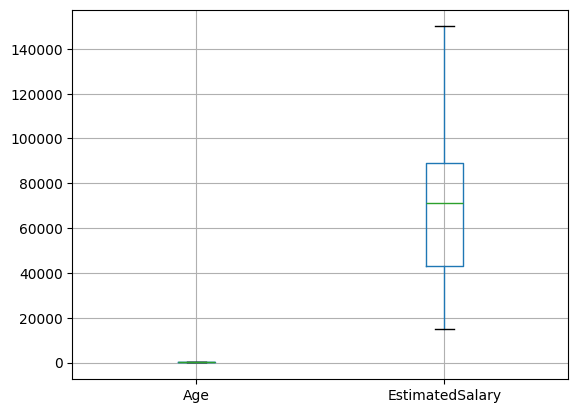

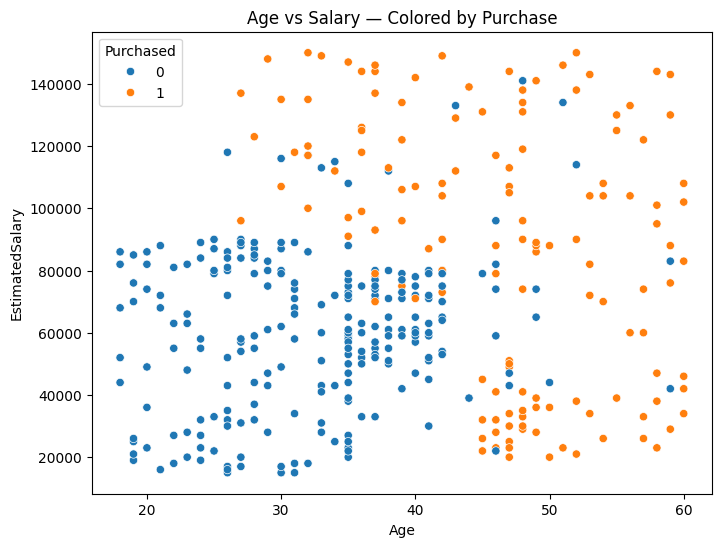

In [121]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='Age', y='EstimatedSalary', hue='Purchased')
plt.title('Age vs Salary — Colored by Purchase')
plt.show()

In [122]:
df['weights']=1/df.shape[0]

In [123]:
df

,Age,EstimatedSalary,Purchased,weights
0,19,19000,0,0.002725
1,35,20000,0,0.002725
2,26,43000,0,0.002725
3,27,57000,0,0.002725
4,19,76000,0,0.002725
...,...,...,...,...
362,46,41000,1,0.002725
363,51,23000,1,0.002725
364,50,20000,1,0.002725
365,36,33000,0,0.002725


In [124]:
dt1 = DecisionTreeClassifier(max_depth=1)

In [125]:
x= df.iloc[:,0:2].values
y= df.iloc[:,2].values

In [126]:
dt1.fit(x,y)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",1
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current 

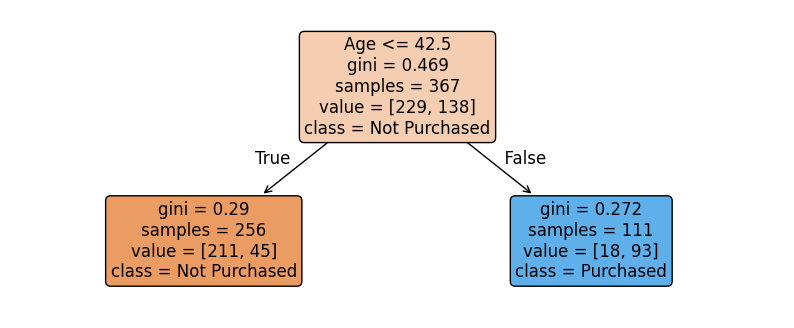

In [127]:

plt.figure(figsize=(10, 4))
plot_tree(dt1, feature_names=['Age', 'EstimatedSalary'], class_names=['Not Purchased', 'Purchased'], filled=True, rounded=True, fontsize=12)
plt.show()

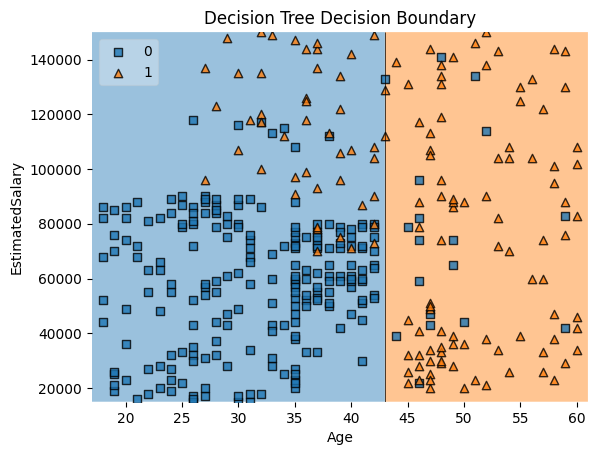

In [128]:
plot_decision_regions(x,y,clf=dt1,legend=2)
plt.xlabel('Age')
plt.ylabel('EstimatedSalary')
plt.title('Decision Tree Decision Boundary')
plt.show()

In [129]:
df['y_pred']=dt1.predict(x)

In [130]:
df

,Age,EstimatedSalary,Purchased,weights,y_pred
0,19,19000,0,0.002725,0
1,35,20000,0,0.002725,0
2,26,43000,0,0.002725,0
3,27,57000,0,0.002725,0
4,19,76000,0,0.002725,0
...,...,...,...,...,...
362,46,41000,1,0.002725,1
363,51,23000,1,0.002725,1
364,50,20000,1,0.002725,1
365,36,33000,0,0.002725,0


In [131]:
error = df.loc[df['Purchased'] != df['y_pred'], 'weights'].sum()
print(error)

0.17166212534059952


In [132]:
def calculate_model_error(error):
    
    return .5*np.log((1-error)/error)

In [133]:
alpha_1=calculate_model_error(error)
alpha_1

np.float64(0.7869464875073443)